<a href="https://colab.research.google.com/github/jahidurmahim/Machine_Learning_Laboratory/blob/main/BackPropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Install Libraries

In [185]:
pip install ucimlrepo

## Load Data

In [186]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

## Combine Features and Target

In [187]:
df = pd.concat([X, y], axis=1)
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Check DataFrame Shape

In [188]:
df.shape

(150, 5)

## Check for Missing Values

In [189]:
df.isna().sum().T

,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class,0


## Check for Duplicate Rows

In [190]:
df.duplicated().sum()

np.int64(3)

## Identify Outliers

In [191]:
outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal width,2.8,3.3,2.05,4.05,4


## Visualize Outliers with Box Plots

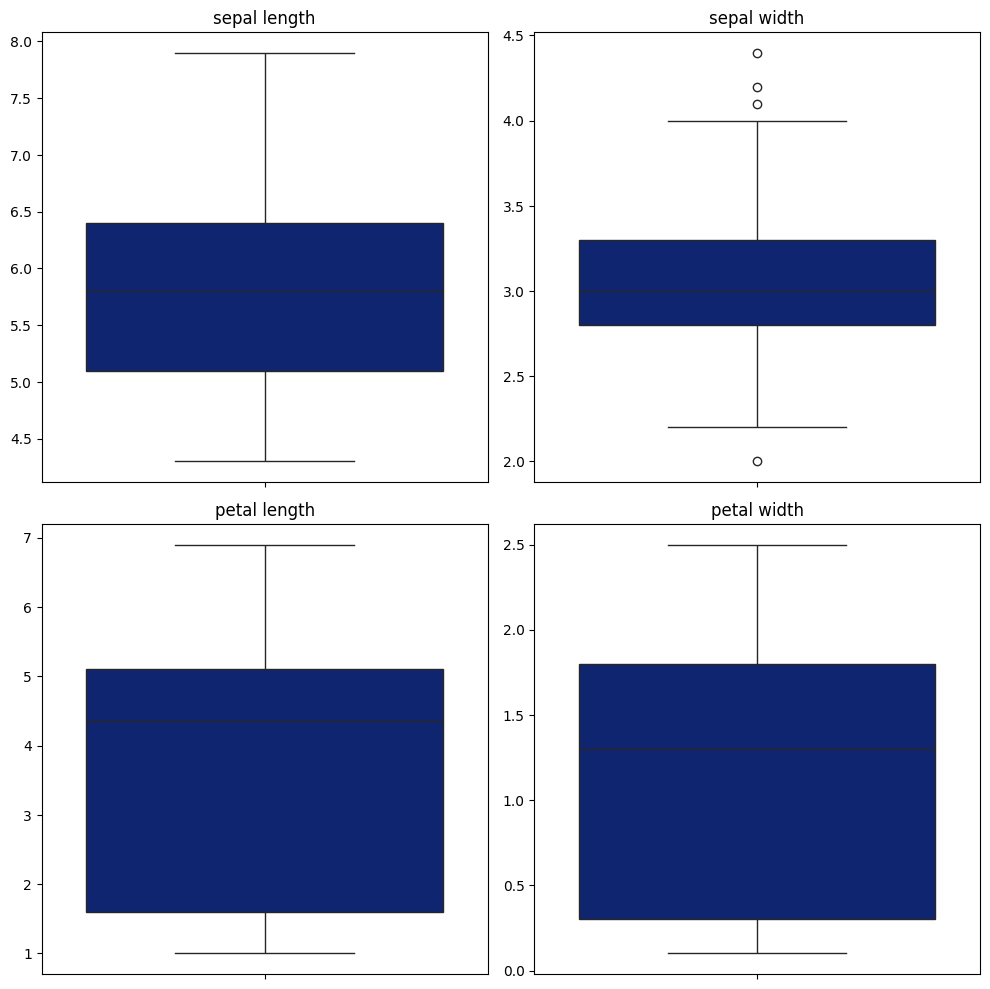

In [192]:
numeric_features = df.select_dtypes(include='number').columns.tolist()

rows = (len(numeric_features) + 1) // 2  # Adjust rows dynamically
cols = 2  # Set columns to 2 for better layout
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Prepare for Outlier Capping

In [193]:
capped_summary = []

numeric_features = df.select_dtypes(include='number').columns.tolist()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

display(capped_df)

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,sepal length,5.1,6.4,3.15,8.35,0
1,sepal width,2.8,3.3,2.05,4.05,0
2,petal length,1.6,5.1,-3.65,10.35,0
3,petal width,0.3,1.8,-1.95,4.05,0


## Apply Outlier Capping and Visualize

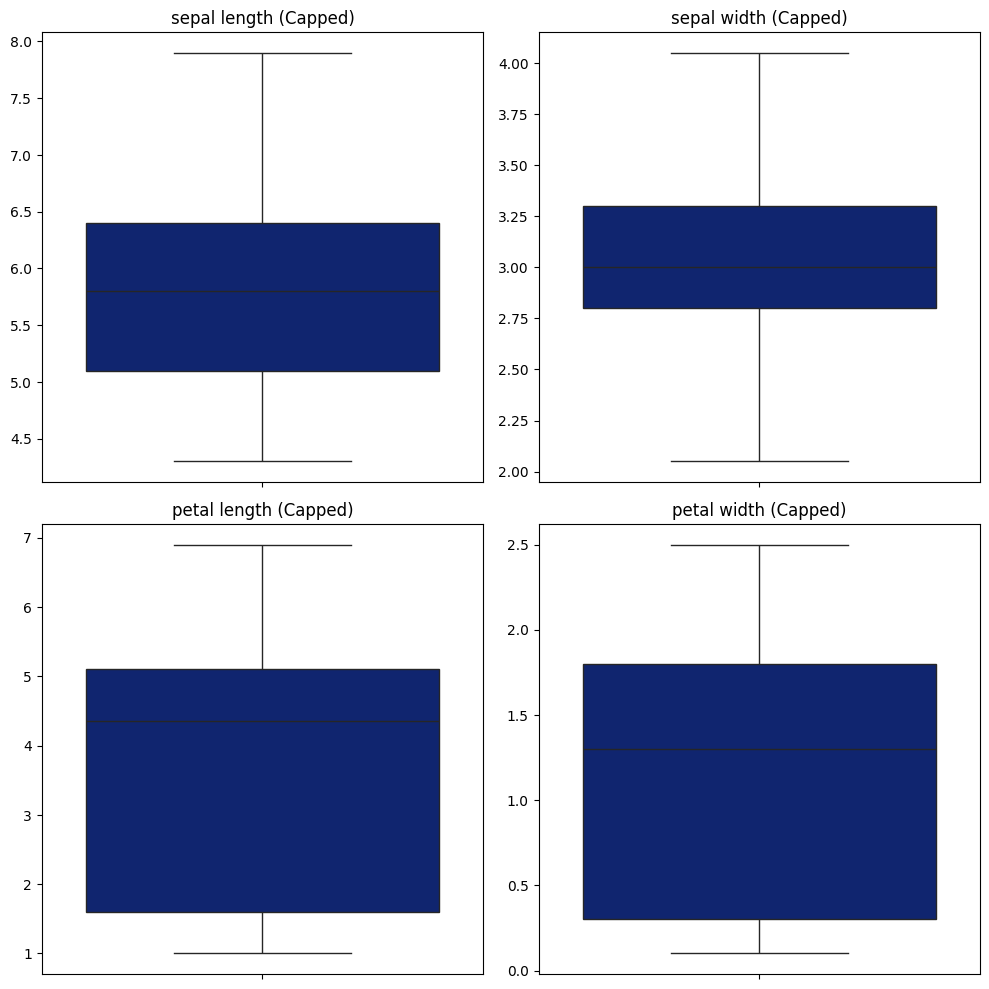

In [194]:
df_capped = df.copy()

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[feature] = df_capped[feature].clip(lower=lower, upper=upper)

numeric_features_capped = df_capped.select_dtypes(include='number').columns.tolist()

rows_capped = (len(numeric_features_capped) + 1) // 2
cols_capped = 2
fig_capped, axes_capped = plt.subplots(rows_capped, cols_capped, figsize=(10, 5 * rows_capped))

axes_capped = axes_capped.flatten()

for i, feature in enumerate(numeric_features_capped):
    sns.boxplot(y=df_capped[feature], ax=axes_capped[i])
    axes_capped[i].set_title(f'{feature} (Capped)')
    axes_capped[i].set_ylabel('')

for j in range(i + 1, len(axes_capped)):
    fig_capped.delaxes(axes_capped[j])

plt.tight_layout()
plt.show()

## Separate Features and Target

In [195]:
X = df.drop("class", axis=1).values
y = df["class"].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(150, 4)
(150, 1)


## Standardize Features

In [196]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Split Data into Training and Testing Sets

In [197]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [198]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [199]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)


(120, 4)
(30, 4)


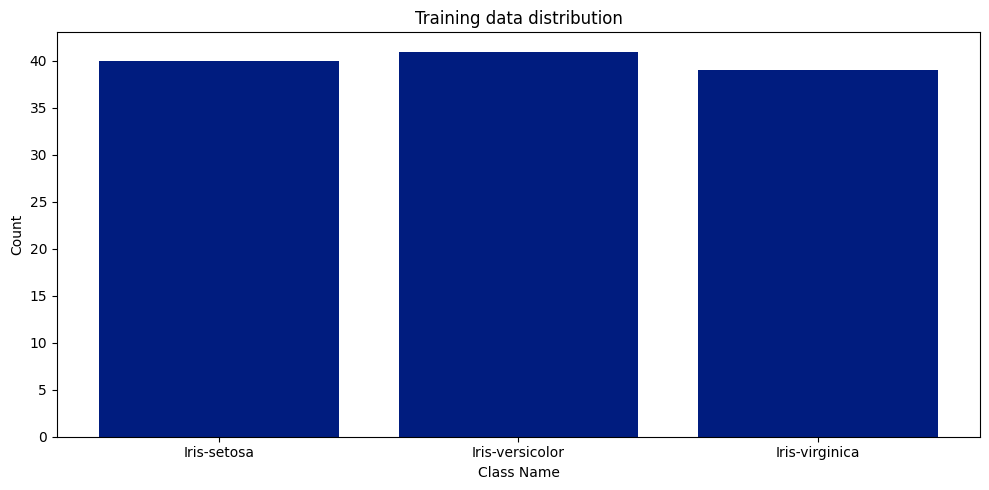

In [200]:
def plot_labels_distribution(data_labels):
    # Flatten the labels if they are in a column vector format
    if data_labels.ndim > 1:
        data_labels = data_labels.flatten()

    # Encode string labels to numerical labels
    le = LabelEncoder()
    encoded_labels = le.fit_transform(data_labels)
    class_names = le.classes_

    counts = np.bincount(encoded_labels)

    plt.style.use('seaborn-v0_8-dark-palette') # Updated style for modern matplotlib

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(range(len(counts)), counts, width=0.8, align='center')
    ax.set(xticks=range(len(counts)), xticklabels=class_names, title='Training data distribution')
    ax.set_xlabel('Class Name')
    ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# Call the function with y_train
plot_labels_distribution(y_train)

In [201]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and y_test
y_train_encoded = le.fit_transform(y_train.flatten())
y_test_encoded = le.transform(y_test.flatten())

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train_encoded)
y_test_one_hot = to_categorical(y_test_encoded)

print("Shape of y_train_one_hot:", y_train_one_hot.shape)
print("Shape of y_test_one_hot:", y_test_one_hot.shape)

Shape of y_train_one_hot: (120, 3)
Shape of y_test_one_hot: (30, 3)


In [202]:
print('Shapes of the prepared data for model training:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train_one_hot shape: {y_train_one_hot.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test_one_hot shape: {y_test_one_hot.shape}')

Shapes of the prepared data for model training:
X_train shape: (120, 4)
y_train_one_hot shape: (120, 3)
X_test shape: (30, 4)
y_test_one_hot shape: (30, 3)


In [203]:
print("Training data")
print(f"- Maximum Value {X_train.max()} ")
print(f"- Minimum Value {X_train.min()} ")

print("\n")

print("Testing data")
print(f"- Maximum Value {X_test.max()} ")
print(f"- Minimum Value {X_test.min()} ")

Training data
- Maximum Value 3.1146839106774356 
- Minimum Value -2.438987252491841 


Testing data
- Maximum Value 2.4920192021244283 
- Minimum Value -1.9761813222277342 


In [204]:
display(y_test_one_hot)

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [205]:
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Import Keras Modules

In [206]:
from keras import models
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Define Neural Network Architecture

In [207]:
# Based on X_train.shape (120, 4), input features are 4.
# Based on y_train_one_hot.shape (120, 3), there are 3 unique labels.
input_features = 4
nb_unique_labels = 3

def define_network_architecture():
    network = Sequential()
    # Input layer: 4 features, 16 neurons for a small dataset
    network.add(Dense(16, activation='relu', input_shape=(input_features,)))
    # Hidden layer: 8 neurons
    network.add(Dense(8, activation='relu'))
    # Output layer: 3 classes, softmax activation for multi-class classification
    network.add(Dense(nb_unique_labels, activation='softmax'))
    return network

## Display Model Summary

In [208]:
network = define_network_architecture()
network.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## Evaluate Model (First Run)

In [209]:
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = network.fit(X_train, y_train_one_hot, epochs=100, batch_size=1)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6910 - loss: 0.8150
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8033 - loss: 0.6764
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9252 - loss: 0.4630
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8756 - loss: 0.3968
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8448 - loss: 0.3684
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8769 - loss: 0.2993
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9254 - loss: 0.2299
Epoch 8/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8989 - loss: 0.2263
Epoch 9/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9185 - loss: 0.2341
Epoch 10/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9066 - loss: 0.2467
Epoch 11/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.1448
Epoch 12/100
120/120 ━━━━━━━━━━━━━━━━━━━━

## Compile and Train Model (First Run)

In [210]:
test_loss, test_accuracy = network.evaluate(X_test, y_test_one_hot)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9333 - loss: 0.0730
Test Loss: 0.0730
Test Accuracy: 0.9333


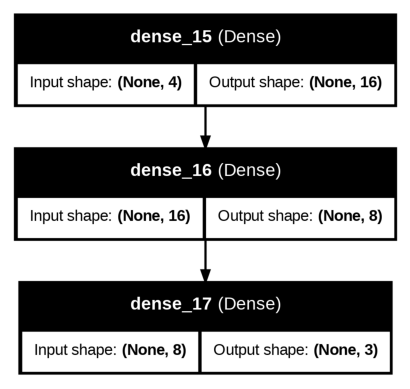

In [211]:
!pip install pydot graphviz

from tensorflow.keras.utils import plot_model

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

plot_model(network, to_file='network_architecture.png', show_shapes=True, show_layer_names=True)

img = mpimg.imread('network_architecture.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## Recompile Model

In [212]:
network.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train Model with Validation Split

In [213]:
# Fit the model
batch_size = 256
n_epochs = 15
val_split = 0.2
patience_value = 5

# Fit the model with the callback
history = network.fit(X_train, y_train_one_hot, validation_split=val_split,
        	epochs=n_epochs, batch_size=batch_size)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9583 - loss: 0.0682 - val_accuracy: 0.9583 - val_loss: 0.0689
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9688 - loss: 0.0605 - val_accuracy: 0.9583 - val_loss: 0.0801
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9792 - loss: 0.0586 - val_accuracy: 0.9583 - val_loss: 0.0854
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9792 - loss: 0.0580 - val_accuracy: 0.9583 - val_loss: 0.0882
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9792 - loss: 0.0577 - val_accuracy: 0.9583 - val_loss: 0.0886
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9792 - loss: 0.0574 - val_accuracy: 0.9583 - val_loss: 0.0890
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9792 - loss: 0.0572 - val_accuracy: 0.9583 - val_loss: 0.0890
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.9792 - loss: 0.0570 - val_accuracy: 0.9583 - val_loss: 0.

## Plot Training and Validation Accuracy

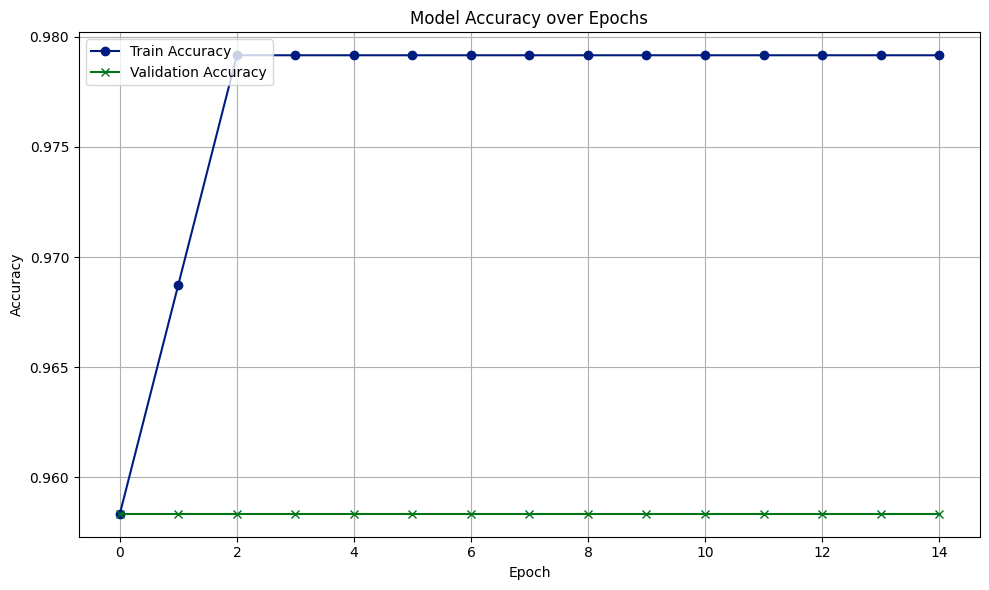

In [214]:
plt.figure(figsize=(10, 6)) # Increased figure size
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o') # Added label and marker
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x') # Added label and marker
plt.title('Model Accuracy over Epochs') # Improved title
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True) # Added grid
plt.tight_layout() # Ensure layout is tight
plt.show()

## Plot Training and Validation Loss

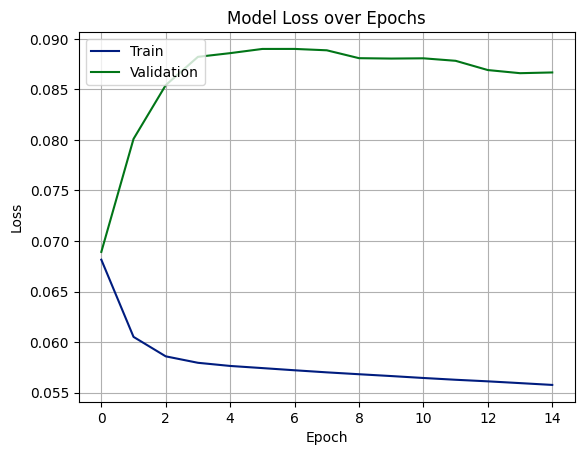

In [220]:

# Plot training & validation loss values
plt.subplot(1, 1, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

## Evaluate Model (Second Run)

In [216]:
loss, acc = network.evaluate(X_test,
                         	y_test_one_hot, batch_size=batch_size)

print("\nTest accuracy: %.1f%%" % (100.0 * acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9667 - loss: 0.0473

Test accuracy: 96.7%
